<a href="https://colab.research.google.com/github/hnur79997-stack/Pert6_Ekstraksi_fitur/blob/main/Ekstraksi_fitur.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import files

In [10]:
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

Saving themetclub.jpg to themetclub (1).jpg


In [11]:
def edge_segmentation(image_path):
    # Baca gambar
    image = cv2.imread(image_path)
    image = cv2.resize(image, (800, 600))

    # =============================
    # 1. GRAYSCALE
    # =============================
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # =============================
    # 2. GAUSSIAN BLUR (REDUCE NOISE)
    # =============================
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # =============================
    # 3. EDGE DETECTION (CANNY)
    # =============================
    edges = cv2.Canny(blur, 50, 150)

    # =============================
    # 4. MORPHOLOGY (PERTEGAS GARIS)
    # =============================
    kernel = np.ones((3,3), np.uint8)
    edges_dilated = cv2.dilate(edges, kernel, iterations=1)

    # =============================
    # 5. OVERLAY KE GAMBAR ASLI
    # =============================
    overlay = image.copy()

    # Warnai garis tepi (merah)
    overlay[edges_dilated != 0] = [0, 0, 255]

    return image, gray, blur, edges, edges_dilated, overlay

1. Citra Asli


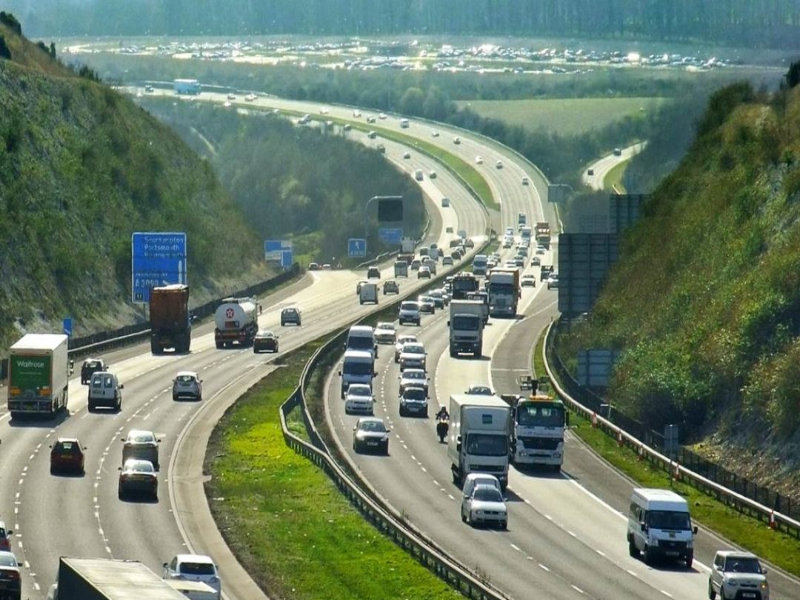

2. Grayscale


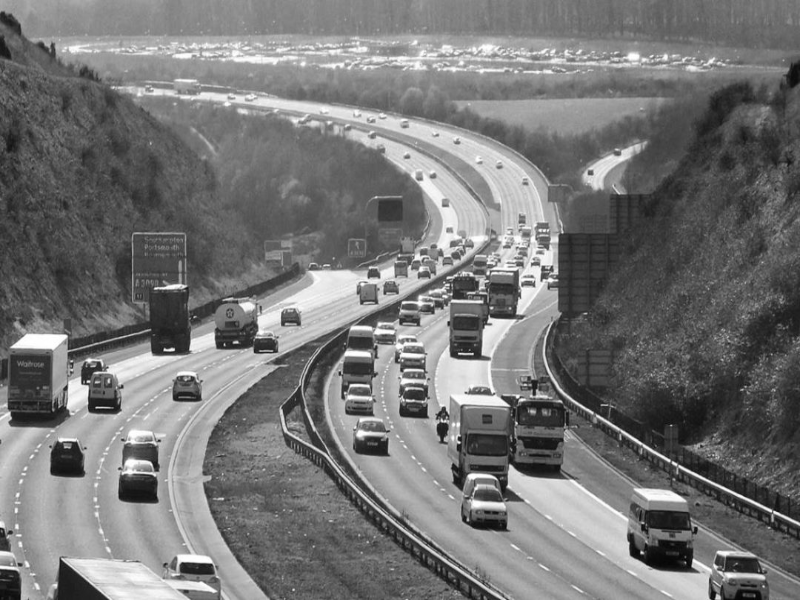

3. Blur


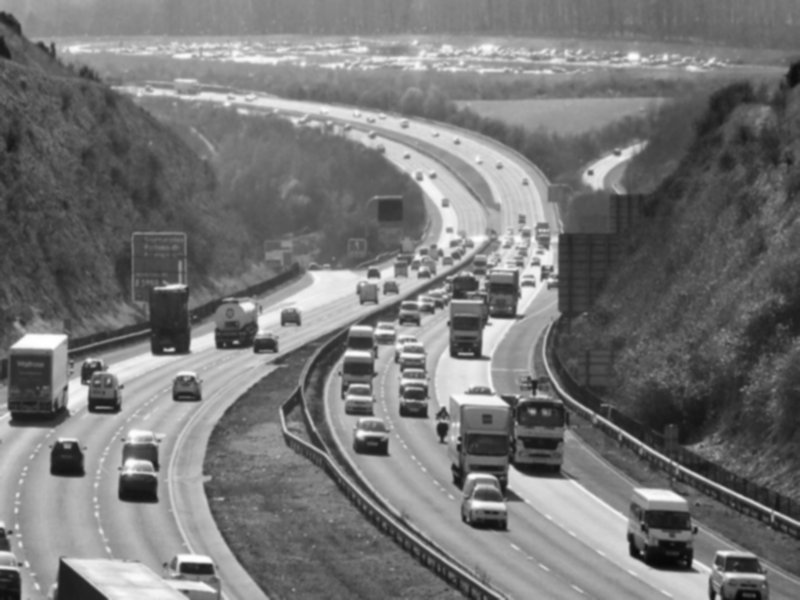

4. Edge Detection (Canny)


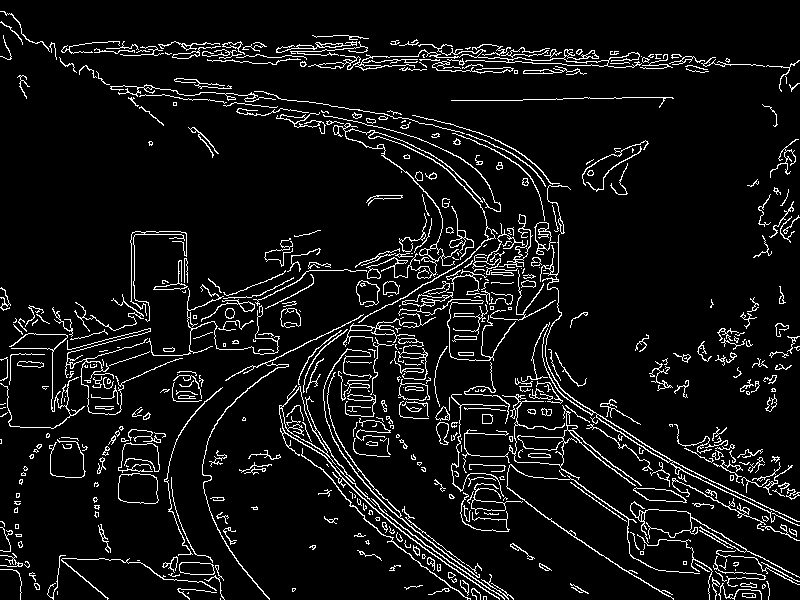

5. Garis Tepi Dipertegas


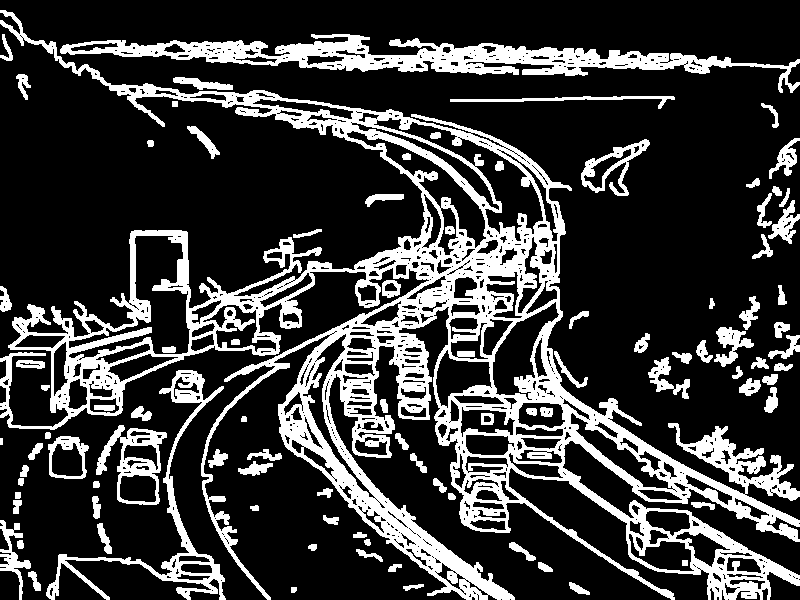

6. Overlay Garis Tepi pada Gambar


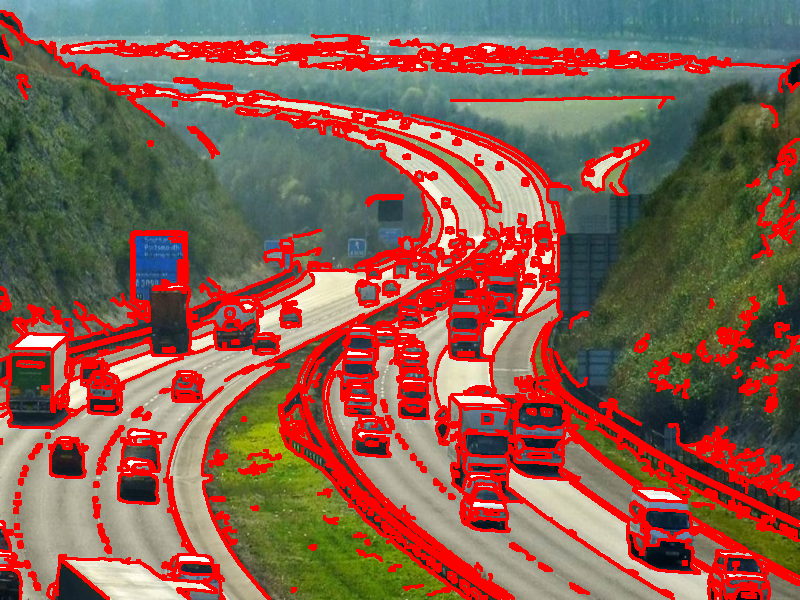

In [12]:
original, gray, blur, edges, edges_dilated, overlay = edge_segmentation(image_path)

print("1. Citra Asli")
cv2_imshow(original)

print("2. Grayscale")
cv2_imshow(gray)

print("3. Blur")
cv2_imshow(blur)

print("4. Edge Detection (Canny)")
cv2_imshow(edges)

print("5. Garis Tepi Dipertegas")
cv2_imshow(edges_dilated)

print("6. Overlay Garis Tepi pada Gambar")
cv2_imshow(overlay)